# Week 3 — LightGBM: Direct-per-Horizon vs. Recursive Multi-Step Forecasting

Two ways to cover all four forecast horizons (`edf.config.HORIZONS`) with LightGBM:

- **Direct**: train a separate model per horizon, each using only the lag/rolling features valid at that horizon (`edf.features.demand.build_feature_table` — same availability rule as `edf.models.baselines.valid_baselines`). No compounding error, but 4 models.
- **Recursive**: train *one* model at the shortest horizon (`30min`, where every lag/rolling feature is valid), then roll it forward step by step for longer horizons, feeding each step's own prediction back in as the next step's short lags (`edf.models.forecast.recursive_forecast`). One model, but errors can compound.

**Scope:** unlike the Week 2 baselines (which don't fit anything and were scored over `TRAIN`+`VALIDATION`), these are trained models — scoring them on `TRAIN` would be in-sample and optimistic. **Every metric here is `VALIDATION` (2024) only.** `TEST` (2025) stays untouched throughout, per the project's correctness rules.

In [1]:
import time

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.evaluate import evaluate
from edf.features.demand import build_feature_table
from edf.models.baselines import previous_week_same_time, valid_baselines
from edf.models.forecast import recursive_forecast, train_lightgbm
from edf.tracking import log_model_run

pd.options.display.float_format = "{:.3f}".format

2026/09/07 08:55:40 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/sidonio.silva/RiderProjects/Personal/energy_demand_forecast/.venv/lib/python3.11/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION
val_index = demand.loc[val_start:val_end].index
len(val_index)

17568

## MASE denominator: seasonal-naive scored on VALIDATION only

Same convention as Weeks 2-3 so far — `previous_week_same_time`'s MAE on the exact window being scored is the one fixed yardstick every model and baseline is measured against.

In [3]:
seasonal_naive_val = previous_week_same_time(demand).loc[val_start:val_end]
naive_mae = evaluate(demand.loc[val_start:val_end], seasonal_naive_val)["mae"]
naive_mae

2027.9001024590164

## Direct models: one LightGBM per horizon

Default hyperparameters (`edf.models.forecast.DEFAULT_LGBM_PARAMS`) — not tuned. Hyperparameter tuning via walk-forward CV is separate Week 3 work; this notebook answers a narrower question (direct vs. recursive), and tuning both strategies identically would just make the comparison slower without changing which one wins.

In [4]:
direct_models = {}
records = []

for horizon_name, periods in config.HORIZONS.items():
    t0 = time.time()
    X, y = build_feature_table(df, horizon_periods=periods)
    X_train, y_train = X.loc[train_start:train_end], y.loc[train_start:train_end]
    X_val, y_val = X.loc[val_start:val_end], y.loc[val_start:val_end]

    model = train_lightgbm(X_train, y_train)
    direct_models[horizon_name] = model

    preds = pd.Series(model.predict(X_val), index=X_val.index)
    metrics = evaluate(y_val, preds, seasonal_naive_mae=naive_mae)
    metrics.update(horizon=horizon_name, strategy="direct")
    records.append(metrics)
    print(f"{horizon_name} direct: {round(time.time() - t0, 1)}s, n_features={X_train.shape[1]}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001026 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4672
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 25
[LightGBM] [Info] Start training from score 26931.631382


30min direct: 4.9s, n_features=26
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4417
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 24
[LightGBM] [Info] Start training from score 26931.631382


1h direct: 4.7s, n_features=25
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4162
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 23
[LightGBM] [Info] Start training from score 26931.631382


1d direct: 4.6s, n_features=24
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001440 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3652
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 21
[LightGBM] [Info] Start training from score 26931.631382


7d direct: 4.6s, n_features=22


## Recursive strategy: roll the `30min` model forward

The `30min` direct model above *is* the recursive base model — at horizon=1 there's no recursion (`recursive_forecast` at `horizon_periods=1` is provably identical to the direct model, see `tests/test_forecast.py`), so it isn't duplicated here.

In [5]:
base_model = direct_models["30min"]

for horizon_name, periods in config.HORIZONS.items():
    if periods == 1:
        continue
    t0 = time.time()
    issue_times = val_index - pd.Timedelta(minutes=30 * periods)
    preds = recursive_forecast(base_model, df, issue_times, horizon_periods=periods)
    y_val = demand.loc[preds.index]

    metrics = evaluate(y_val, preds, seasonal_naive_mae=naive_mae)
    metrics.update(horizon=horizon_name, strategy="recursive")
    records.append(metrics)
    print(f"{horizon_name} recursive: {round(time.time() - t0, 1)}s ({periods} steps)")

1h recursive: 0.1s (2 steps)


1d recursive: 1.7s (48 steps)


7d recursive: 12.0s (336 steps)


## Comparison table: direct vs. recursive vs. every valid baseline, per horizon

In [6]:
for horizon_name, periods in config.HORIZONS.items():
    baseline_preds = {
        name: fn(demand).loc[val_start:val_end]
        for name, fn in valid_baselines(periods).items()
    }
    for name, preds in baseline_preds.items():
        metrics = evaluate(demand.loc[preds.index], preds, seasonal_naive_mae=naive_mae)
        metrics.update(horizon=horizon_name, strategy=f"baseline:{name}")
        records.append(metrics)

results = pd.DataFrame(records).set_index(["horizon", "strategy"]).sort_index()
results[["mae", "rmse", "mape", "mase"]]

mae     rmse  mape  mase
horizon strategy                                                             
1d      baseline:persistence                    1901.851 2640.039 7.400 0.938
        baseline:previous_day_same_time         1901.851 2640.039 7.400 0.938
        baseline:previous_week_same_time        2027.900 2686.538 7.740 1.000
        baseline:trailing_moving_average        2334.694 3005.908 9.077 1.151
        baseline:trailing_weekly_moving_average 2054.453 2719.224 7.762 1.013
        direct                                  1262.780 1680.388 4.921 0.623
        recursive                               1285.203 1710.238 5.043 0.634
1h      baseline:persistence                    1271.291 1691.931 4.865 0.627
        baseline:previous_day_same_time         1901.851 2640.039 7.400 0.938
        baseline:previous_week_same_time        2027.900 2686.538 7.740 1.000
        baseline:trailing_moving_average        2334.694 3005.908 9.077 1.151
        baseline:trailing_weekly_moving_average 2054.453 2719.224 7.762 1.013
        direct                                   364.659  478.904 1.404 0.180
        recursive                                348.155  455.256 1.344 0.172
30min   baseline:persistence                     657.216  881.278 2.521 0.324
        baseline:previous_day_same_time         1901.851 2640.039 7.400 0.938
        baseline:previous_week_same_time        2027.900 2686.538 7.740 1.000
        baseline:trailing_moving_average        2334.694 3005.908 9.077 1.151
        baseline:trailing_weekly_moving_average 2054.453 2719.224 7.762 1.013
        direct                                   212.366  277.767 0.823 0.105
7d      baseline:persistence                    2027.900 2686.538 7.740 1.000
        baseline:previous_week_same_time        2027.900 2686.538 7.740 1.000
        baseline:trailing_weekly_moving_average 2054.453 2719.224 7.762 1.013
        direct                                  1585.577 2109.147 6.073 0.782
        recursive                               1670.545 2235.276 6.394 0.824

## Finding: recursive is competitive at 1 extra step, then falls behind

| horizon | direct MASE | recursive MASE | recursive vs. direct |
|---|---|---|---|
| `30min` | 0.105 | *(= direct)* | — |
| `1h` (2 steps) | 0.180 | **0.172** | recursive slightly *better* |
| `1d` (48 steps) | 0.623 | 0.634 | direct slightly better |
| `7d` (336 steps) | 0.782 | 0.824 | direct clearly better |

At `1h`, recursive edges out direct — with only one recursive step, the compounding cost is negligible, and the recursive base model gets to use `lag_1`/`lag_2` (via its own one-step-ahead prediction as a proxy) that the direct `1h` model has to do without entirely, since those lags are shorter than a 2-period horizon and therefore invalid for it. That proxy is informative enough to outweigh the small compounding cost at this horizon.

By `1d` (48 steps) the two are close but direct has pulled ahead, and by `7d` (336 steps) the gap is clear — compounding error catches up with the recursive strategy roughly where the theory predicted it would: the more sequential steps, the more it costs. **Recommendation: use direct per-horizon models for `1d` and `7d`; recursive is a reasonable, cheaper choice for `1h` if only one model is wanted.**

The more important result for the project, though: **both strategies beat every baseline at every horizon**, including `7d`, where the best baseline (seasonal-naive, MASE = 1.0 by construction) is beaten by direct LightGBM at MASE ≈ 0.78 — the model is learning real structure (mainly annual seasonality, see feature importance below), not just leaning on the same lags the baselines already use.

## Plot: MASE by horizon, direct vs. recursive vs. the strongest baseline

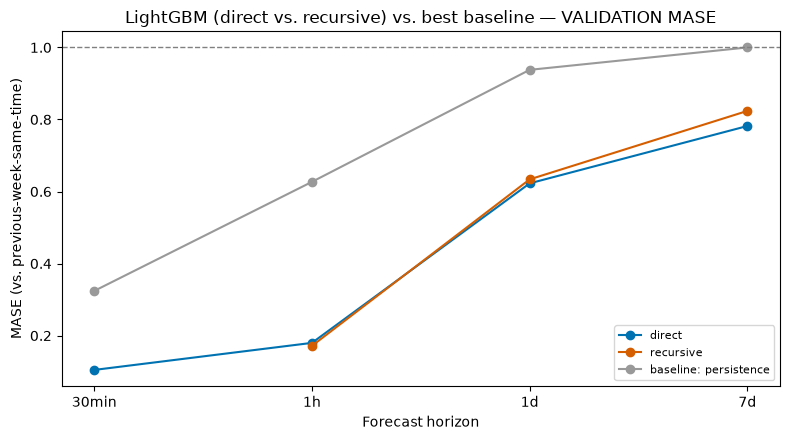

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {"direct": "#0072B2", "recursive": "#D55E00", "baseline:persistence": "#999999"}
horizon_names = list(config.HORIZONS)

for strategy, color in colors.items():
    ys, xs = [], []
    for h in horizon_names:
        if (h, strategy) in results.index:
            xs.append(h)
            ys.append(results.loc[(h, strategy), "mase"])
    label = strategy.replace("baseline:", "baseline: ")
    ax.plot(xs, ys, marker="o", label=label, color=color)

ax.axhline(1.0, color="grey", linestyle="--", linewidth=1)
ax.set_title("LightGBM (direct vs. recursive) vs. best baseline — VALIDATION MASE")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("MASE (vs. previous-week-same-time)")
ax.legend(fontsize=8)
fig.tight_layout()

## Feature importance sanity check (`1d` direct model)

PLAN.md's Week 3 expectation was that `lag_336` and `hour_of_day` would dominate. What actually dominates is **annual seasonality** (the Fourier terms) — which lines up with this project's own weather-exploration finding that temperature is the single biggest external driver of GB demand, so it's a sensible result even though it isn't the one originally guessed. `lag_48` (previous day, the same lag as the horizon itself), weekly structure (`fourier_weekly_*`/`day_of_week`), and the two trailing-average baseline features all show up with real importance too — `lag_336` and `hour_of_day` matter, just less than the top few.

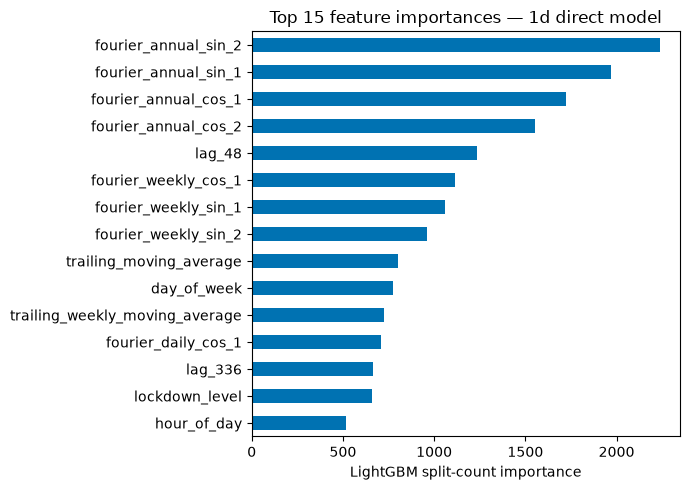

In [8]:
model_1d = direct_models["1d"]
importance = (
    pd.Series(model_1d.feature_importances_, index=model_1d.feature_name_)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(7, 5))
importance.iloc[::-1].plot.barh(ax=ax, color="#0072B2")
ax.set_title("Top 15 feature importances — 1d direct model")
ax.set_xlabel("LightGBM split-count importance")
fig.tight_layout()

## Log every (horizon, strategy) run to MLflow

In [9]:
for (horizon_name, strategy), row in results.iterrows():
    if strategy.startswith("baseline:"):
        continue  # baselines were already logged in notebook 05
    fold_metrics = pd.DataFrame([row[["mae", "rmse", "mape", "mase"]]], index=pd.Index([2024], name="year"))
    log_model_run(
        horizon_name=horizon_name,
        horizon_periods=config.HORIZONS[horizon_name],
        model_name="lightgbm",
        fold_metrics=fold_metrics,
        extra_tags={"strategy": strategy},
    )
print("Logged direct + recursive runs to MLflow under ../mlruns/mlflow.db")

Logged direct + recursive runs to MLflow under ../mlruns/mlflow.db
